In [1119]:
import torch
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import seaborn as sns


from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import os
import re


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## Non-logic helper functions

In [1120]:
def load_tensor(path: Path):
    assert path.exists(), path
    return torch.load(path, map_location="cpu")

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


## Helper functions

In [1121]:


# -------------------------------------------------------------
# Get information about dataset and model 
# -------------------------------------------------------------

def get_data_dir_name_from_log(experiment_path: Path):
    log_path = experiment_path / "log.txt"
    assert log_path.exists(), log_path

    data_dir_line = None
    with log_path.open("r") as f:
        for line in f:
            if line.startswith("data_dir:"):
                data_dir_line = line.split("data_dir:", 1)[1].strip()
                break
            if line.startswith("Loading existing synthetic dataset from"):
                data_dir_line = line.split("Loading existing synthetic dataset from", 1)[1].strip()
                break

    if data_dir_line is None:
        raise ValueError(f"Could not find data directory in {log_path}")

    return Path(data_dir_line).name

def infer_data_path(experiment_path: Path):
    cfg = read_config_from_log(experiment_path)
    data_cfg = cfg["data"]
    dataset = data_cfg["dataset"]
    difficulty = data_cfg.get("experiment_type")
    data_dir_name = get_data_dir_name_from_log(experiment_path)



    candidate = Path("datasets") / dataset / difficulty / data_dir_name


    if candidate.exists():
        return candidate

    raise FileNotFoundError("Could not find data path. Tried: " + ", ".join(map(str, candidate)))


def print_data_info(experiment_path: Path):
    data_path = infer_data_path(experiment_path)
    with open(data_path / "info.txt", "r") as f:
        info_lines = f.readlines()
        for line in info_lines:
            print(line.strip())
            



def read_config_from_log(experiment_path: Path):
    log_path = experiment_path / "log.txt"
    assert log_path.exists(), log_path
    with log_path.open("r") as f:
        first_line = f.readline().strip()
    return ast.literal_eval(first_line)

def infer_dataset_difficulty_from_log(experiment_path: Path):
    cfg = read_config_from_log(experiment_path)
    data_cfg = cfg["data"]
    difficulty = data_cfg.get("experiment_type")
    return difficulty





def get_dim_data_and_model(experiment_path: Path):
    cfg = read_config_from_log(experiment_path)
    num_concepts = cfg["data"].get("num_concepts")
    num_residuals = cfg["data"].get("num_residuals")
    hid_dim = cfg["data"]["hid_dim"]
    obs_dim = cfg["data"]["obs_dim"]
    if num_concepts is None or num_residuals is None:
        raise ValueError(f"Could not find num_concepts or num_residuals in config: {cfg}")
    return num_concepts, num_residuals, hid_dim, obs_dim



# --------------------------------------------------------------
# Load data
# --------------------------------------------------------------
def load_split(experiment_path: Path, data_path: Path, split: str, num_concepts=None, num_residuals=None):
    model_split = experiment_path / split
    data_split = data_path / split

    if not model_split.exists():
        raise FileNotFoundError(
            f"Missing {model_split}. Re-run inference/training after adding deterministic analysis loaders."
        )
    assert data_split.exists(), data_split
    


    c_res_mu = load_tensor(model_split / "c_res_mu.pt")
    concept_residual_probs = load_tensor(model_split / "concepts_residuals_pred_probs_mean.pt")
    concept_residual_probs_std = load_tensor(model_split / "concepts_residuals_pred_probs_std.pt")
    concept_residual_sample_mean = load_tensor(model_split / "concepts_residuals_sample_mean.pt")
    
    res_mu = c_res_mu[:, num_concepts:]
    c_mu = c_res_mu[:, :num_concepts]
    concept_probs = concept_residual_probs[:, :num_concepts]
    residual_probs = concept_residual_probs[:, num_concepts:]
    concept_probs_std = concept_residual_probs_std[:, :num_concepts]
    residual_probs_std = concept_residual_probs_std[:, num_concepts:]
    concept_sample_mean = concept_residual_sample_mean[:, :num_concepts]
    residual_sample_mean = concept_residual_sample_mean[:, num_concepts:]
        
        


    out = {
        "res_mu": res_mu,
        "c_mu": c_mu,
        "concept_probs": concept_probs,
        "residual_probs": residual_probs,
        "concept_probs_std": concept_probs_std,
        "residual_probs_std": residual_probs_std,
        "concept_sample_mean": concept_sample_mean,
        "residual_sample_mean": residual_sample_mean,
        "hidden_residuals": load_tensor(data_split / "residuals.pt"),
        "hidden_residual_signal": load_tensor(data_split / "residual_signal.pt"),
        "concepts": load_tensor(data_split / "concepts.pt"),
        "concept_signal": load_tensor(data_split / "concept_signal.pt"),
        "x": load_tensor(data_split / "x.pt"),
        "y": load_tensor(data_split / "y.pt"),
        "w_hid": load_tensor(data_split / "w_hid.pt"),
        "w_obs": load_tensor(data_split / "w_obs.pt"), 
        "s": load_tensor(data_split / "s.pt")
    }



    # Ensure number of samples in model outputs matches number of samples in data
    n_model = out["res_mu"].shape[0]
    n_data = out["hidden_residuals"].shape[0]
    assert n_model == n_data, (
        f"{split} row mismatch: model residuals have {n_model} rows, "
        f"but hidden residual labels have {n_data}. The residual dump likely used a shuffled/drop_last loader."
    )
    assert out["residual_probs"].shape[0] == n_data
    assert out["residual_sample_mean"].shape[0] == n_data

    return out








# -------------------------------------------------------------
# Test metrics of concept model and linear model
# --------------------------------------------------------------
def get_metrics_dataset_linear_model(full_model_path, dataset_difficulty, dataset="synthetic_res_scbm", get_res_used_model=False):
    full_data_path = get_data_dir_name_from_log(full_model_path)
    data_dir_name = full_data_path.split("/")[-1]
    print(f"data_dir_name: {data_dir_name}")
    linear_models_dir = os.path.join("experiments", "linear_head", dataset, dataset_difficulty)
    linear_model_path = None
    if get_res_used_model:
        model_name_start = data_dir_name + "_trueResUsed_True"
    else:
        model_name_start = data_dir_name + "_trueResUsed_False"
    for model_dir in os.listdir(linear_models_dir):
        if model_dir.startswith(model_name_start):
            linear_model_path = model_dir
            break
    if linear_model_path is None:
        return None  # No matching linear model found
    with open(os.path.join(linear_models_dir, linear_model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Test" in line:
                test_line = line
                break
        y_accuracy = re.findall(r"Final Test Accuracy:\s*([0-9.]+)", test_line)[0]
        
    return float(y_accuracy)


def test_metrics(full_model_path):
    metrics = {}
    with open(os.path.join(full_model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Test" in line:
                test_line = line
                break
        y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", test_line)[0]
        c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", test_line)[0]
        c_auc = re.findall(r"c_AUROC:\s*([0-9.]+)", test_line)[0]
        metrics["y_accuracy"] = float(y_accuracy)
        metrics["c_accuracy"] = float(c_accuracy)
        metrics["c_auc"] = float(c_auc)
    return metrics  



def test_metrics_regression(full_model_path):
    metrics = {}
    with open(os.path.join(full_model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Test" in line:
                test_line = line
                break
        y_mse = re.findall(r"y_mse:\s*([0-9.]+)", test_line)[0]
        c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", test_line)[0]
        c_auc = re.findall(r"c_AUROC:\s*([0-9.]+)", test_line)[0]
        
        metrics["y_mse"] = float(y_mse)
        metrics["c_accuracy"] = float(c_accuracy)
        metrics["c_auc"] = float(c_auc)
    return metrics




def test_metrics_scbm_model(full_model_path_scbm_residual):
    data_difficulty = infer_dataset_difficulty_from_log(full_model_path_scbm_residual)
    scbm_root_dir =  Path(f"experiments/scbm/synthetic_res_scbm/{data_difficulty}/")
    
    full_model_path_scbm_residual_str = str(full_model_path_scbm_residual)
    # for example retrieve everything after "hard/" in the path to get the relative path
    relative_path = full_model_path_scbm_residual_str.split(data_difficulty + "/")[1]
    
    # Relative path for corresponding scbm and residual scbm experiments should be the same up until date and time
    if "L_int_extension_loss_weight_1" in relative_path:
        scbm_model_start_name = relative_path.split("L_int_extension_loss_weight")[0] 
    else:
        scbm_model_start_name = relative_path.split("2026-")[0]

    
    
    full_scbm_model_path = None
    for model_dir in os.listdir(scbm_root_dir):
        if model_dir.startswith(scbm_model_start_name):
            full_scbm_model_path = scbm_root_dir / model_dir
            break
    
    if full_scbm_model_path is not None:
        test_metrics_scbm = test_metrics(full_scbm_model_path)
        return test_metrics_scbm
    else:
        print(f"No matching SCBM model found for {full_model_path_scbm_residual}")
        return None





# -------------------------------------------------------------
# Edit final dataframes
# --------------------------------------------------------------


def add_weights(df, w_hid, column_name="hidden_concept_idx"):
    if not column_name in df.columns:
        raise ValueError(f"DataFrame must contain {column_name} column to add weights.")
   
    # Add weights to the DataFrame based on hidden_idx
    df["w_hid"] = df[column_name].apply(lambda idx: w_hid[idx].item() if idx < len(w_hid) else None)
    df["abs_w_hid"] = df["w_hid"].abs()
    df.sort_values(by="abs_w_hid", ascending=False, inplace=True)
    return df






## Post-analysis helper functions

In [1122]:
def calculate_auc(true_val, pred_val):
    auc = roc_auc_score(true_val, pred_val)
    if auc < 0.5:
        print("Warning: AUC < 0.5, inverting predictions.")
        auc = 1 - auc
        direction = "negative"
    else:
        direction = "positive"
    return auc, direction



## Dataset helper functions

In [1123]:
def load_split_data(full_data_path, split):
    data_path = Path(full_data_path)
    data_split = data_path / split
    assert data_path.exists(), data_path
    
    concepts = load_tensor(data_split / "concepts.pt")
    x = load_tensor(data_split / "x.pt")
    y = load_tensor(data_split / "y.pt")
    w_hid = load_tensor(data_split / "w_hid.pt")
    w_obs = load_tensor(data_split / "w_obs.pt")
    residuals = load_tensor(data_split / "residuals.pt")
    
    return {
        "concepts": concepts,
        "x": x,
        "y": y,
        "w_hid": w_hid,
        "w_obs": w_obs,
        "residuals": residuals
    }
    
    
def print_data_info_from_data_path(full_data_path):
    data_path = Path(full_data_path)
    info_file = data_path / "info.txt"
    assert info_file.exists(), info_file
    with open(info_file, "r") as f:
        for line in f:
            print(line.strip())

    

    
    

## Specify experiment

### Old experiments

In [1124]:

# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                        "alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_hard_hid20_R20_sparse_200_epochs_save_c_res_2026-06-15_22-56-15_16428"
# )

# Sigma_x = 0.1, easy dataset
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/easy/"
#                        "alpha_1.0_beta_1.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_TEST_DATA_SET_2026-06-16_16-16-11_10b94"
# )

# # Sigma_x = 0.5, easy dataset
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/easy/"
#                        "alpha_1.0_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_TEST_DATA_SET_2026-06-16_17-51-47_c78ba"
# )

# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                        "alpha_1.0_beta_1.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_hard_hid20_R20_sparse_200_epochs_2026-06-17_13-22-33_ba6fd"
# )

# alpha = 0.5, beta = 2.0, num_concepts = 10, num_residuals = 20, sigma_x = 0.5
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                        "alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_hard_hid20_R20_sparse_200_epochs_save_c_res_2026-06-15_22-56-15_16428"
# )

# alpha = 1.0, beta = 1.0, num_concepts = 10, num_residuals = 20
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                        "alpha_1.0_beta_1.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_hard_hid20_R20_sparse_200_epochs_2026-06-17_13-22-33_ba6fd"
# )
        

# alpha = 0.5, beta = 2.0, num_concepts = 10, num_residuals = 20
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                        "alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_hard_hid20_R20_sparse_200_epochs_2026-06-17_15-26-23_74fe2"
# )
      
      
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                         "alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_hard_hid50_R50_sparse_200_epochs_2026-06-18_18-27-03_23384"                     
# )
                     

# L_int extension loss, alpha = 0.5, beta = 2.0, num_concepts = 10, num_residuals = 20
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                        "alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_hard_hid20_R20_sparse_200_epochs_L_int_extension_loss_weight_1_2026-06-20_20-11-31_3f004"
# )

# Regression task, alpha = 0.5, beta = 2.0, num_concepts = 10, num_residuals = 20
EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm_old/hard/"
                       "alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_regression_hard_hid20_R20_sparse_200_epochs_2026-06-20_18-58-12_80cca"
)

DATA_PATH = "/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/datasets/synthetic_res_scbm_old/hard/cluster_a_0.5_b_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.1_hid_dim_20_obs_dim_10_seed_0_regression"


### New experiments

In [1125]:
# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                        "alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_hid20_R20_sparse_200_epochs_L_int_extension_loss_weight_1_2026-06-22_11-30-42_fdb31"
# )

# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                        "alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.01_hid20_R20_sparse_200_epochs_L_int_extension_loss_weight_1_2026-06-22_11-30-53_68e50"
# )

# EXPERIMENT_PATH = Path("experiments/scbm_residual/synthetic_res_scbm/hard/"
#                        "alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.5_hid20_R20_sparse_200_epochs_L_int_extension_loss_weight_1_2026-06-22_11-30-44_2c662"
# )




In [1126]:
REGRESSION_TASK = "regression" in str(EXPERIMENT_PATH)




assert EXPERIMENT_PATH.exists(), EXPERIMENT_PATH
EXPERIMENT_PATH

#DATA__PATH = infer_data_path(EXPERIMENT_PATH)

PosixPath('experiments/scbm_residual/synthetic_res_scbm_old/hard/alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_regression_hard_hid20_R20_sparse_200_epochs_2026-06-20_18-58-12_80cca')

## Datasets and model specifications

In [1127]:
num_concepts, num_residuals, hid_dim, obs_dim = get_dim_data_and_model(EXPERIMENT_PATH)
print(f"num_concepts: {num_concepts}, num_residuals: {num_residuals}, hid_dim: {hid_dim}, obs_dim: {obs_dim}")

# Load data splits
train_data = load_split(EXPERIMENT_PATH, DATA__PATH, "train", num_concepts=num_concepts, num_residuals=num_residuals)
val_data = load_split(EXPERIMENT_PATH, DATA__PATH, "val", num_concepts=num_concepts, num_residuals=num_residuals)
test_data = load_split(EXPERIMENT_PATH, DATA__PATH, "test", num_concepts=num_concepts, num_residuals=num_residuals)

splits = {"train": train_data, "val": val_data, "test": test_data}

for split_name, data in splits.items():
    print(f"{split_name} split:")
    for key in ["x", "res_mu", "residual_probs", "residual_sample_mean", "hidden_residuals", "hidden_residual_signal", "concepts", "y"]:
        print(f"  {key:24s} {tuple(data[key].shape)}")

num_concepts: 10, num_residuals: 20, hid_dim: 20, obs_dim: 10
train split:
  x                        (30000, 100)
  res_mu                   (30000, 20)
  residual_probs           (30000, 20)
  residual_sample_mean     (30000, 20)
  hidden_residuals         (30000, 20)
  hidden_residual_signal   (30000, 20)
  concepts                 (30000, 10)
  y                        (30000,)
val split:
  x                        (10000, 100)
  res_mu                   (10000, 20)
  residual_probs           (10000, 20)
  residual_sample_mean     (10000, 20)
  hidden_residuals         (10000, 20)
  hidden_residual_signal   (10000, 20)
  concepts                 (10000, 10)
  y                        (10000,)
test split:
  x                        (10000, 100)
  res_mu                   (10000, 20)
  residual_probs           (10000, 20)
  residual_sample_mean     (10000, 20)
  hidden_residuals         (10000, 20)
  hidden_residual_signal   (10000, 20)
  concepts                 (10000, 10)
  y     

### Dataset weights

In [1128]:

w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]

w_hid_and_w_obs = torch.cat([w_hid, w_obs], dim=0)

df_w_hid = pd.DataFrame({
    "hidden_concept_idx": [i for i in range(w_hid.shape[0])],
    "weight": w_hid.detach().cpu().numpy(),
    "abs_weight": w_hid.abs().detach().cpu().numpy(),
})

df_w_obs = pd.DataFrame({
    "observed_concept_idx": [i for i in range(w_obs.shape[0])],
    "weight": w_obs.detach().cpu().numpy(),
    "abs_weight": w_obs.abs().detach().cpu().numpy(),
})

df_w_hid = df_w_hid[df_w_hid["abs_weight"] > 1e-8]
df_w_obs = df_w_obs[df_w_obs["abs_weight"] > 1e-8]

df_w_hid = df_w_hid.sort_values("abs_weight", ascending=False)
df_w_obs = df_w_obs.sort_values("abs_weight", ascending=False)

display(df_w_hid)
display(df_w_obs)


data_difficulty = infer_dataset_difficulty_from_log(EXPERIMENT_PATH)
print(f"Dataset difficulty: {data_difficulty}")
print_data_info(EXPERIMENT_PATH)

,hidden_concept_idx,weight,abs_weight
18,18,-0.705692,0.705692
2,2,-0.648612,0.648612
9,9,0.230210,0.230210
19,19,-0.150507,0.150507
7,7,0.075182,0.075182


,observed_concept_idx,weight,abs_weight
0,0,0.916100,0.916100
3,3,-0.384910,0.384910
7,7,0.112267,0.112267


Dataset difficulty: hard


TypeError: 'PosixPath' object is not iterable

## Model performance

In [1142]:


dataset_difficulty = infer_dataset_difficulty_from_log(EXPERIMENT_PATH)
linear_y_with_residuals = get_metrics_dataset_linear_model(EXPERIMENT_PATH, dataset_difficulty=dataset_difficulty, dataset="synthetic_res_scbm", get_res_used_model=True)
linear_y_without_residuals = get_metrics_dataset_linear_model(EXPERIMENT_PATH, dataset_difficulty=dataset_difficulty, dataset="synthetic_res_scbm", get_res_used_model=False)

if REGRESSION_TASK:
    test_metrics_dict = test_metrics_regression(EXPERIMENT_PATH)
else:
    test_metrics_dict = test_metrics(EXPERIMENT_PATH)
test_metrics_dict["linear_model_y_accuracy_with_res"] = linear_y_with_residuals
test_metrics_dict["linear_model_y_accuracy_no_res"] = linear_y_without_residuals
test_metrics_scbm = test_metrics_scbm_model(EXPERIMENT_PATH)
test_metrics_dict["scbm_y_accuracy"] = test_metrics_scbm["y_accuracy"] if test_metrics_scbm is not None else None
test_metrics_dict["scbm_c_accuracy"] = test_metrics_scbm["c_accuracy"] if test_metrics_scbm is not None else None
test_metrics_dict["scbm_c_auc"] = test_metrics_scbm["c_auc"] if test_metrics_scbm is not None else None

test_metrics_df = pd.DataFrame([test_metrics_dict])



display(test_metrics_df)

data_dir_name: cluster_a_0.5_b_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.1_hid_dim_20_obs_dim_10_seed_0_regression
data_dir_name: cluster_a_0.5_b_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.1_hid_dim_20_obs_dim_10_seed_0_regression
No matching SCBM model found for experiments/scbm_residual/synthetic_res_scbm_old/hard/alpha_0.5_beta_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_sigma_x_0.1_regression_hard_hid20_R20_sparse_200_epochs_2026-06-20_18-58-12_80cca


,y_mse,c_accuracy,c_auc,linear_model_y_accuracy_with_res,linear_model_y_accuracy_no_res,scbm_y_accuracy,scbm_c_accuracy,scbm_c_auc
0,0.134,0.885,0.939,None,None,None,None,None


## Distributed probe baseline

Train a seperate logistic regression model for each hidden concept, to see how much of the hidden concept information is stored in the full residual channel

In [1143]:
def probe_baseline(H_pred_train, H_true_train, H_pred_test, H_true_test, column_name="hidden_idx"):
    H_pred_train = to_numpy(H_pred_train).astype(float)
    H_pred_test = to_numpy(H_pred_test).astype(float)
    H_true_train = to_numpy(H_true_train).astype(float)
    H_true_test = to_numpy(H_true_test).astype(float)
    
    output = []

    # For each hidden concept, fit logistic regression model 
    for h in range(H_true_train.shape[1]):
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0))
        clf.fit(H_pred_train, H_true_train[:, h])
        probs = clf.predict_proba(H_pred_test)[:, 1]
        preds = (probs >= 0.5).astype(int)
        
        output.append({
            column_name: h,
            "distributed_auc": roc_auc_score(H_true_test[:, h], probs),
            "distributed_accuracy": accuracy_score(H_true_test[:, h], preds),
            "distributed_f1": f1_score(H_true_test[:, h], preds),
        })

    return pd.DataFrame(output)
        
    
    
probe_eval_hidden = probe_baseline(
    splits["train"]["res_mu"],
    splits["train"]["hidden_residuals"],
    splits["test"]["res_mu"],
    splits["test"]["hidden_residuals"],
    column_name="hidden_concept_idx"
)

df_probe_eval_hidden = add_weights(probe_eval_hidden, w_hid)
display(df_probe_eval_hidden.head(15))
    
    

,hidden_concept_idx,distributed_auc,distributed_accuracy,distributed_f1,w_hid,abs_w_hid
18,18,0.764149,0.6991,0.673041,-0.705692,0.705692
2,2,0.751442,0.6939,0.667102,-0.648612,0.648612
9,9,0.607567,0.5775,0.596196,0.230210,0.230210
19,19,0.589600,0.5640,0.558704,-0.150507,0.150507
7,7,0.583157,0.5593,0.551906,0.075182,0.075182
12,12,0.617094,0.5830,0.583832,0.000000,0.000000
17,17,0.591309,0.5665,0.569556,0.000000,0.000000
16,16,0.583247,0.5616,0.562911,0.000000,0.000000
15,15,0.544771,0.5317,0.531653,0.000000,0.000000
14,14,0.552536,0.5448,0.545255,0.000000,0.000000


In [1144]:
# Calculate AUC for observed concepts, to be used as upper bound for hidden concepts
probe_eval_observed = probe_baseline(
    splits["train"]["c_mu"],
    splits["train"]["concepts"],
    splits["test"]["c_mu"],
    splits["test"]["concepts"],
    column_name="concept_idx"
)

df_probe_eval_observed = add_weights(probe_eval_observed, w_obs, column_name="concept_idx")
display(df_probe_eval_observed.head(15))
    

,concept_idx,distributed_auc,distributed_accuracy,distributed_f1,w_hid,abs_w_hid
0,0,0.940846,0.8800,0.880240,0.916100,0.916100
3,3,0.933806,0.8699,0.867637,-0.384910,0.384910
7,7,0.941062,0.8866,0.884002,0.112267,0.112267
1,1,0.945088,0.8848,0.883424,0.000000,0.000000
2,2,0.948764,0.8916,0.890593,0.000000,0.000000
4,4,0.942075,0.8820,0.880081,0.000000,0.000000
5,5,0.942061,0.8821,0.880535,0.000000,0.000000
6,6,0.929318,0.8668,0.863497,0.000000,0.000000
8,8,0.931898,0.8694,0.867599,0.000000,0.000000
9,9,0.946019,0.8877,0.886140,0.000000,0.000000


## MLP predicting from raw input x

In [1145]:

# Predict observed concepts directly from raw input x with a small MLP.
# Targets are multi-label binary concepts, so the model emits one logit per concept.

class ConceptMLP(nn.Module):
    def __init__(self, input_dim, num_concepts, hidden_dims=(128, 64), dropout=0.1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_concepts))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_concept_loader(split_data, batch_size=512, shuffle=False, prediction_column="concepts"):
    dataset = torch.utils.data.TensorDataset(
        split_data["x"].float(),
        split_data[prediction_column].float(),
    )
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# Run inference with MLP
def evaluate_concept_mlp(model, loader, device, prediction_column="concepts"):
    model.eval()
    losses = []
    all_logits = []
    all_targets = []
    with torch.no_grad():
        for xb, cb in loader:
            xb = xb.to(device)
            cb = cb.to(device)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, cb)
            losses.append(loss.item() * xb.shape[0])
            all_logits.append(logits.cpu())
            all_targets.append(cb.cpu())

    logits = torch.cat(all_logits)
    targets = torch.cat(all_targets)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()

    metrics = {
        "loss": sum(losses) / len(loader.dataset),
        "element_accuracy": (preds == targets).float().mean().item(),
        "exact_match_accuracy": (preds == targets).all(dim=1).float().mean().item(),
        "macro_f1": f1_score(to_numpy(targets), to_numpy(preds), average="macro", zero_division=0),
    }

    try:
        per_concept_auc = [
            roc_auc_score(to_numpy(targets[:, j]), to_numpy(probs[:, j]))
            for j in range(targets.shape[1])
            if len(np.unique(to_numpy(targets[:, j]))) > 1
        ]
        metrics["macro_auc"] = float(np.mean(per_concept_auc))
    except ValueError:
        metrics["macro_auc"] = np.nan
        
        
        
        
    per_concept_metrics = []

    if prediction_column == "concepts":
        column_idx = "concept_idx"
    else:
        column_idx = "hidden_concept_idx"



    for j in range(targets.shape[1]):
        y_true = to_numpy(targets[:, j])
        y_prob = to_numpy(probs[:, j])
        y_pred = to_numpy(preds[:, j])

        row = {
            column_idx: j,
            "accuracy": accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        }

        if len(np.unique(y_true)) > 1:
            row["auc"] = roc_auc_score(y_true, y_prob)
        else:
            row["auc"] = np.nan

        per_concept_metrics.append(row)
    

    metrics["per_concept_metrics"] = pd.DataFrame(per_concept_metrics)

    return metrics, probs

# Train MLP
def train_concept_mlp_from_x(
    train_data,
    val_data,
    test_data,
    hidden_dims=(128, 64),
    dropout=0.1,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=512,
    epochs=100,
    patience=10,
    prediction_column="concepts"
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    x_mean = train_data["x"].float().mean(dim=0, keepdim=True)
    x_std = train_data["x"].float().std(dim=0, keepdim=True).clamp_min(1e-6)
    normalized_splits = {}
    for split_name, split_data in {"train": train_data, "val": val_data, "test": test_data}.items():
        normalized_splits[split_name] = dict(split_data)
        normalized_splits[split_name]["x"] = (split_data["x"].float() - x_mean) / x_std

    train_loader = make_concept_loader(normalized_splits["train"], batch_size=batch_size, shuffle=True, prediction_column=prediction_column)
    val_loader = make_concept_loader(normalized_splits["val"], batch_size=batch_size, prediction_column=prediction_column)
    test_loader = make_concept_loader(normalized_splits["test"], batch_size=batch_size, prediction_column=prediction_column)

    model = ConceptMLP(
        input_dim=train_data["x"].shape[1],
        num_concepts=train_data[prediction_column].shape[1],
        hidden_dims=hidden_dims,
        dropout=dropout,
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, cb in train_loader:
            xb = xb.to(device)
            cb = cb.to(device)
            optimizer.zero_grad()
            loss = F.binary_cross_entropy_with_logits(model(xb), cb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.shape[0]
        train_loss /= len(train_loader.dataset)

        val_metrics, _ = evaluate_concept_mlp(model, val_loader, device, prediction_column=prediction_column)
        history.append({"epoch": epoch, "train_loss": train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}})

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)
    test_metrics, test_concept_probs_from_x = evaluate_concept_mlp(model, test_loader, device, prediction_column=prediction_column)
    per_concept_metrics = test_metrics.pop("per_concept_metrics")
    metrics = pd.DataFrame([test_metrics], index=["test"])
    return {
        "model": model,
        "metrics": metrics,
        "history": pd.DataFrame(history),
        "best_epoch": best_epoch,
        "x_mean": x_mean,
        "x_std": x_std,
        "test_concept_probs_from_x": test_concept_probs_from_x,
        "per_concept_metrics": per_concept_metrics,
    }


concept_mlp_results = train_concept_mlp_from_x(train_data, val_data, test_data, prediction_column="concepts")
print(f"Best validation epoch: {concept_mlp_results['best_epoch']}")
display(concept_mlp_results["metrics"][["loss", "element_accuracy", "exact_match_accuracy", "macro_f1", "macro_auc"]])
print(concept_mlp_results["per_concept_metrics"])
# Macro AUC is the average AUC across concepts


Best validation epoch: 15


,loss,element_accuracy,exact_match_accuracy,macro_f1,macro_auc
test,0.504611,0.74636,0.0507,0.727872,0.817195


   concept_idx  accuracy        f1       auc
0            0    0.7468  0.731666  0.814439
1            1    0.7509  0.732237  0.824676
2            2    0.7615  0.742246  0.834746
3            3    0.7322  0.716973  0.803333
4            4    0.7469  0.726349  0.818289
5            5    0.7500  0.731009  0.821999
6            6    0.7325  0.708828  0.798810
7            7    0.7631  0.742863  0.834594
8            8    0.7240  0.708369  0.792861
9            9    0.7557  0.738185  0.828201


In [1146]:
concept_mlp_results = train_concept_mlp_from_x(train_data, val_data, test_data, prediction_column="hidden_residuals")
print(f"Best validation epoch: {concept_mlp_results['best_epoch']}")
display(concept_mlp_results["metrics"][["loss", "element_accuracy", "exact_match_accuracy", "macro_f1", "macro_auc"]])


print(concept_mlp_results["per_concept_metrics"])

Best validation epoch: 62


,loss,element_accuracy,exact_match_accuracy,macro_f1,macro_auc
test,0.510806,0.741905,0.0017,0.715715,0.81171


    hidden_concept_idx  accuracy        f1       auc
0                    0    0.7594  0.729602  0.830967
1                    1    0.7309  0.700834  0.804863
2                    2    0.7553  0.732481  0.823132
3                    3    0.7244  0.701861  0.793305
4                    4    0.7595  0.730169  0.829581
5                    5    0.7523  0.720901  0.821322
6                    6    0.7621  0.742281  0.835330
7                    7    0.7440  0.708627  0.807896
8                    8    0.7229  0.685792  0.788737
9                    9    0.7424  0.729979  0.812457
10                  10    0.7462  0.715343  0.812015
11                  11    0.7423  0.724415  0.813069
12                  12    0.7230  0.697202  0.791258
13                  13    0.7377  0.709556  0.802806
14                  14    0.7418  0.711766  0.813617
15                  15    0.7595  0.740253  0.834613
16                  16    0.7507  0.719415  0.819510
17                  17    0.7470  0.724821  0.

## Raw axis analysis

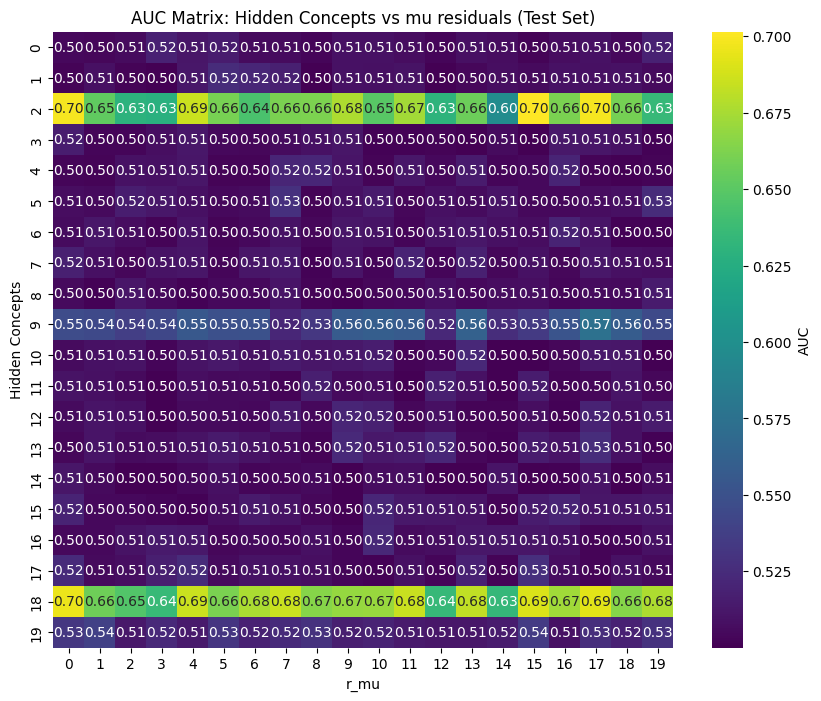

,idx,weight,abs_weight
20,obs_0,0.916100,0.916100
18,hid_18,-0.705692,0.705692
2,hid_2,-0.648612,0.648612
23,obs_3,-0.384910,0.384910
9,hid_9,0.230210,0.230210
19,hid_19,-0.150507,0.150507
27,obs_7,0.112267,0.112267
7,hid_7,0.075182,0.075182


In [1147]:
def calculate_auc(true_val, pred_val):
    auc = roc_auc_score(true_val, pred_val)
    if auc < 0.5:
        auc = 1 - auc
        direction = "negative"
    else:
        direction = "positive"
    return auc


def matrix_to_dataframe(matrix, row_title="hidden_idx", col_title="residual_idx", value_name="auc"):
    rows, cols = np.indices(matrix.shape)
    df = pd.DataFrame({
        row_title: rows.ravel(),
        col_title: cols.ravel(),
        value_name: matrix.ravel(),
    })
    return df

def auc_matrix(hidden_concepts, residuals):
    num_hidden_concepts = hidden_concepts.shape[1]
    num_residuals = residuals.shape[1]
    
    # Create matrix to store AUC values
    aucs_matrix = np.zeros((num_hidden_concepts, num_residuals))
    for j in range(num_hidden_concepts):
        for k in range(num_residuals):
            if len(np.unique(hidden_concepts[:, j])) > 1:
                aucs_matrix[j, k] = calculate_auc(hidden_concepts[:, j], residuals[:, k])
            else:
                aucs_matrix[j, k] = np.nan
                
   
  
    
    
    return aucs_matrix


auc_matrix_test = auc_matrix(to_numpy(test_data["hidden_residuals"]), to_numpy(test_data["res_mu"]))

def plot_heatmap(auc_matrix, title="AUC Matrix: Hidden Concepts vs Residuals (Test Set)", x_label="c_res", y_label="Hidden Concepts"):
    if sns is None:
        raise ImportError("Seaborn is not installed. Please install seaborn to plot heatmaps.")
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(auc_matrix, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'AUC'})
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

plot_heatmap(auc_matrix_test, title="AUC Matrix: Hidden Concepts vs mu residuals (Test Set)", x_label="r_mu", y_label="Hidden Concepts")


# make dataframe with hidden_idx, resisual idx as columns and AUC as values
# auc_test_df = matrix_to_dataframe(auc_matrix_test, row_title="hidden_idx", col_title="residual_idx", value_name="auc")

# auc_test_df = add_weights(auc_test_df, w_hid, column_name="hidden_idx")

# display(auc_test_df.sort_values("abs_w_hid", ascending=False).head(40))


w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]

w_hid_and_w_obs = torch.cat([w_hid, w_obs], dim=0)

idx = [f"hid_{i}" for i in range(w_hid.shape[0])] + [f"obs_{i}" for i in range(w_obs.shape[0])]
df_w_hid_and_w_obs = pd.DataFrame({
    "idx": idx,
    "weight": w_hid_and_w_obs.detach().cpu().numpy(),
    "abs_weight": w_hid_and_w_obs.abs().detach().cpu().numpy(),
})

# only display non-zero abs weights
df_w_hid_and_w_obs = df_w_hid_and_w_obs[df_w_hid_and_w_obs["abs_weight"] > 1e-8]
display(df_w_hid_and_w_obs.sort_values("abs_weight", ascending=False))


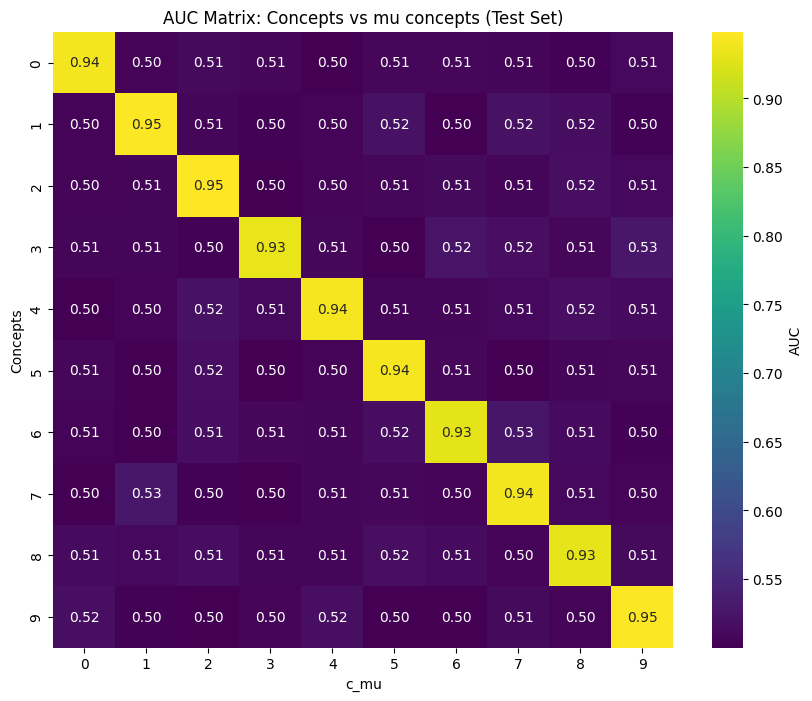

,idx,weight,abs_weight
20,obs_0,0.916100,0.916100
18,hid_18,-0.705692,0.705692
2,hid_2,-0.648612,0.648612
23,obs_3,-0.384910,0.384910
9,hid_9,0.230210,0.230210
19,hid_19,-0.150507,0.150507
27,obs_7,0.112267,0.112267
7,hid_7,0.075182,0.075182


In [1148]:
auc_matrix_test = auc_matrix(to_numpy(test_data["concepts"]), to_numpy(test_data["c_mu"]))

plot_heatmap(auc_matrix_test, title="AUC Matrix: Concepts vs mu concepts (Test Set)", x_label="c_mu", y_label="Concepts")


w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]

w_hid_and_w_obs = torch.cat([w_hid, w_obs], dim=0)

idx = [f"hid_{i}" for i in range(w_hid.shape[0])] + [f"obs_{i}" for i in range(w_obs.shape[0])]
df_w_hid_and_w_obs = pd.DataFrame({
    "idx": idx,
    "weight": w_hid_and_w_obs.detach().cpu().numpy(),
    "abs_weight": w_hid_and_w_obs.abs().detach().cpu().numpy(),
})

# only display non-zero abs weights
df_w_hid_and_w_obs = df_w_hid_and_w_obs[df_w_hid_and_w_obs["abs_weight"] > 1e-8]
display(df_w_hid_and_w_obs.sort_values("abs_weight", ascending=False))


## Correlation analysis within residual channel

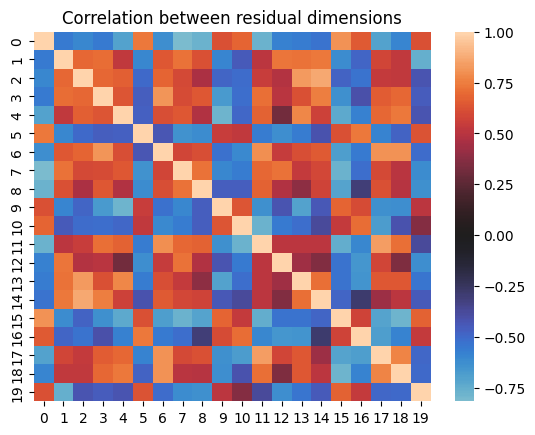

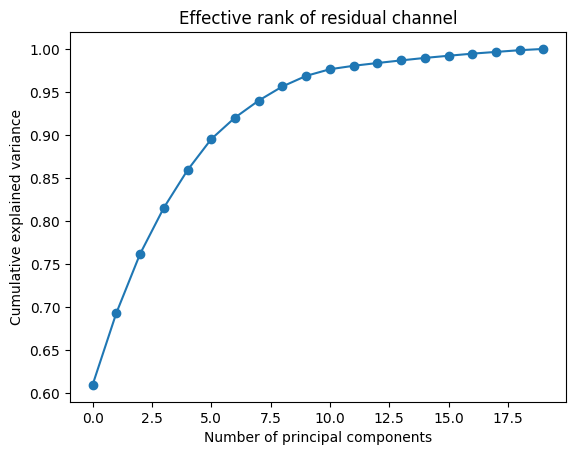

Top singular values: [679.96576  251.40111  228.07378  201.48407  182.13359  165.40582
 137.48065  122.50818  111.433716  96.55878 ]
Cumulative explained variance: [0.6099113  0.69328463 0.76190346 0.81545526 0.8592148  0.8953054
 0.9202385  0.94003654 0.95641696 0.96871614]


In [1149]:
R = to_numpy(test_data["res_mu"])

corr = np.corrcoef(R.T)
sns.heatmap(corr, center=0)
plt.title("Correlation between residual dimensions")
plt.show()

u, s, vh = np.linalg.svd(R - R.mean(axis=0), full_matrices=False)
explained = s**2 / np.sum(s**2)

plt.plot(np.cumsum(explained), marker="o")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Effective rank of residual channel")
plt.show()

print("Top singular values:", s[:10])
print("Cumulative explained variance:", np.cumsum(explained)[:10])

# Fit PCA on residual channel, and compute AUC between principal components and true hidden concepts

In [1150]:
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

R = to_numpy(test_data["res_mu"])
H = to_numpy(test_data["hidden_residuals"])  # or hidden concept labels

R_centered = R - R.mean(axis=0)

pca = PCA(n_components=5)
Z = pca.fit_transform(R_centered)

rows = []
# Compute auc between top 5 principal components and each hidden concept
for pc_idx in range(5):
    for h_idx in range(H.shape[1]):
        auc = roc_auc_score(H[:, h_idx], Z[:, pc_idx])
        auc_abs = max(auc, 1 - auc)
        rows.append({
            "pc": pc_idx + 1,
            "hidden_concept_idx": h_idx,
            "auc": auc,
            "auc_abs": auc_abs,
            "explained_variance": pca.explained_variance_ratio_[pc_idx],
        })

pc_hidden_auc = pd.DataFrame(rows)
pc_hidden_auc.sort_values(["pc", "auc_abs"], ascending=[True, False]).head(20)

,pc,hidden_concept_idx,auc,auc_abs,explained_variance
18,1,18,0.265977,0.734023,0.609912
2,1,2,0.280903,0.719097,0.609912
9,1,9,0.564637,0.564637,0.609912
19,1,19,0.472936,0.527064,0.609912
17,1,17,0.485276,0.514724,0.609912
16,1,16,0.489505,0.510495,0.609912
13,1,13,0.489646,0.510354,0.609912
5,1,5,0.510344,0.510344,0.609912
3,1,3,0.492883,0.507117,0.609912
0,1,0,0.493368,0.506632,0.609912


### AUC score between Principal components of res_mu and hidden task score 

In [1151]:
hidden_concept_signal = test_data["hidden_residual_signal"]

R = to_numpy(test_data["res_mu"])

w_hid = test_data["w_hid"]  # adjust key if needed

hidden_score = hidden_concept_signal @ w_hid
full_score = test_data["s"]


R_centered = R - R.mean(axis=0)
pca = PCA(n_components=5)
Z = pca.fit_transform(R_centered)

corr = np.corrcoef(Z[:, 0], hidden_score)[0, 1]
print("corr(PC1, hidden task score):", corr)

auc_hidden_score = roc_auc_score(test_data["y"], hidden_score)
auc_pc1_y = roc_auc_score(test_data["y"], Z[:, 0])



print("AUC hidden score -> y:", max(auc_hidden_score, 1 - auc_hidden_score))
print("AUC PC1 -> y:", max(auc_pc1_y, 1 - auc_pc1_y))




corr(PC1, hidden task score): 0.8782505596230662
AUC hidden score -> y: 0.9850199846505528
AUC PC1 -> y: 0.9420661399445296


In [1152]:
from sklearn.linear_model import Ridge, Lasso

from sklearn.metrics import r2_score



pc1 = Z[:, 0]
H = to_numpy(test_data["hidden_residual_signal"])
w_hid = to_numpy(test_data["w_hid"])

lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.001, max_iter=10000)
)

lasso.fit(H, pc1)
pred = lasso.predict(H)

coefs = lasso.named_steps["lasso"].coef_

lasso_df = pd.DataFrame({
    "hidden_concept_idx": np.arange(H.shape[1]),
    "coef_pc1_on_h": coefs,
    "abs_coef": np.abs(coefs),
    "w_hid": w_hid,
    "abs_w_hid": np.abs(w_hid),
})

print("R2 hidden concepts -> PC1:", r2_score(pc1, pred))
lasso_df.sort_values("abs_coef", ascending=False)

R2 hidden concepts -> PC1: 0.7793437242507935


,hidden_concept_idx,coef_pc1_on_h,abs_coef,w_hid,abs_w_hid
18,18,-4.285514,4.285514,-0.705692,0.705692
2,2,-4.015384,4.015384,-0.648612,0.648612
9,9,0.991518,0.991518,0.230210,0.230210
19,19,-0.588263,0.588263,-0.150507,0.150507
7,7,0.260096,0.260096,0.075182,0.075182
4,4,0.116686,0.116686,0.000000,0.000000
14,14,-0.102227,0.102227,0.000000,0.000000
3,3,-0.093143,0.093143,0.000000,0.000000
15,15,-0.078031,0.078031,0.000000,0.000000
17,17,-0.070326,0.070326,0.000000,0.000000


### Ensure that our task score calculation is correct

In [1153]:
concept_signal = test_data["concept_signal"]
residual_signal = test_data["hidden_residual_signal"]
config = read_config_from_log(EXPERIMENT_PATH)
alpha = config["data"]["alpha"]
beta = config["data"]["beta"]

s_concepts = concept_signal @ w_obs
s_residuals = residual_signal @ w_hid

s = alpha * s_concepts + beta * s_residuals
s_true = test_data["s"]

print(type(s), s.shape)
print(type(s_true), s_true.shape)
# check if s and s_true are close
s_diff = torch.abs(s - s_true)
print("Max difference between computed s and true s:", s_diff.max().item())
print("Mean difference:", s_diff.mean().item())
print("All close:", torch.allclose(s, s_true, atol=1e-6))

<class 'torch.Tensor'> torch.Size([10000])
<class 'torch.Tensor'> torch.Size([10000])
Max difference between computed s and true s: 9.5367431640625e-07
Mean difference: 4.905396977505916e-08
All close: True


/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_40015/3643775579.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  s_residuals = residual_signal @ w_hid


## Try different datasets

In [1154]:

root = "/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/datasets/synthetic_res_scbm/"
data_difficulty = "hard"

#relative_data_dir_name = "cluster_a_0.5_b_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.1_seed_0"
relative_data_dir_name = "cluster_a_0.5_b_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.5_seed_0"
full_data_path = f"{root}/{data_difficulty}/{relative_data_dir_name}"

# check if path exists
assert os.path.exists(full_data_path), f"Data path does not exist: {full_data_path}"
print_data_info_from_data_path(full_data_path)





train_data = load_split_data(full_data_path, "train")
val_data = load_split_data(full_data_path, "val")
test_data = load_split_data(full_data_path, "test")

w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]

w_hid_and_w_obs = torch.cat([w_hid, w_obs], dim=0)

idx = [f"hid_{i}" for i in range(w_hid.shape[0])] + [f"obs_{i}" for i in range(w_obs.shape[0])]
df_w_hid_and_w_obs = pd.DataFrame({
    "idx": idx,
    "weight": w_hid_and_w_obs.detach().cpu().numpy(),
    "abs_weight": w_hid_and_w_obs.abs().detach().cpu().numpy(),
})

df_w_hid_and_w_obs = df_w_hid_and_w_obs.sort_values("abs_weight", ascending=False)
df_w_hid_and_w_obs = df_w_hid_and_w_obs[df_w_hid_and_w_obs["abs_weight"] > 1e-8]
display(df_w_hid_and_w_obs)
    

concept_mlp_results = train_concept_mlp_from_x(train_data, val_data, test_data)
print(f"Best validation epoch: {concept_mlp_results['best_epoch']}")
display(concept_mlp_results["metrics"][["loss", "element_accuracy", "exact_match_accuracy", "macro_f1", "macro_auc"]])

print(concept_mlp_results["per_concept_metrics"])





AssertionError: Data path does not exist: /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/datasets/synthetic_res_scbm//hard/cluster_a_0.5_b_2.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.5_seed_0

In [ ]:
import numpy as np

num_classes = 5
y = np.array([0, 1, 2, 1, 0, 3, 4, 2, 1, 0])  # Example labels

class_counts = np.bincount(y, minlength=num_classes)
class_counts 

array([3, 3, 2, 1, 1])